In [37]:
import pandas as pd

import hvplot.pandas

import holoviews as hv

import matplotlib.pyplot as plt

print("Imports successful!")

Imports successful!


In [55]:
# Create an API call to the NOAA NCEI database

ncei_url = ('https://www.ncei.noaa.gov/access/services/data/v1'

           '?dataset=daily-summaries'

           '&dataTypes=TOBS'

           '&stations=USC00112931'

           '&startDate=1895-07-07'

           '&endDate=2026-07-20'

           '&units=standard')

ncei_url

'https://www.ncei.noaa.gov/access/services/data/v1?dataset=daily-summaries&dataTypes=TOBS&stations=USC00112931&startDate=1895-07-07&endDate=2026-07-20&units=standard'

In [66]:
# Open and clean the data

fairfield_df = pd.read_csv(

    ncei_url,

    na_values=["-99"],

    index_col="DATE",

    parse_dates=["DATE"]

)

fairfield_df

,STATION,TOBS
DATE,,
1895-07-07,USC00112931,NaN
1895-07-08,USC00112931,NaN
1895-07-14,USC00112931,NaN
1895-07-15,USC00112931,NaN
1895-07-19,USC00112931,NaN
...,...,...
2026-07-16,USC00112931,75.0
2026-07-17,USC00112931,74.0
2026-07-18,USC00112931,76.0


In [67]:
# Keep only the TOBS column

fairfield_df = fairfield_df[["TOBS"]]

fairfield_df.head()
fairfield_df.tail()

,TOBS
DATE,
2026-07-16,75.0
2026-07-17,74.0
2026-07-18,76.0
2026-07-19,75.0
2026-07-20,71.0


In [68]:
# To show the start where valid Data Exist
fairfield_df[fairfield_df["TOBS"].notna()].head()

,TOBS
DATE,
1901-01-01,16.0
1901-01-02,20.0
1901-01-03,22.0
1901-01-04,39.0
1901-01-05,34.0


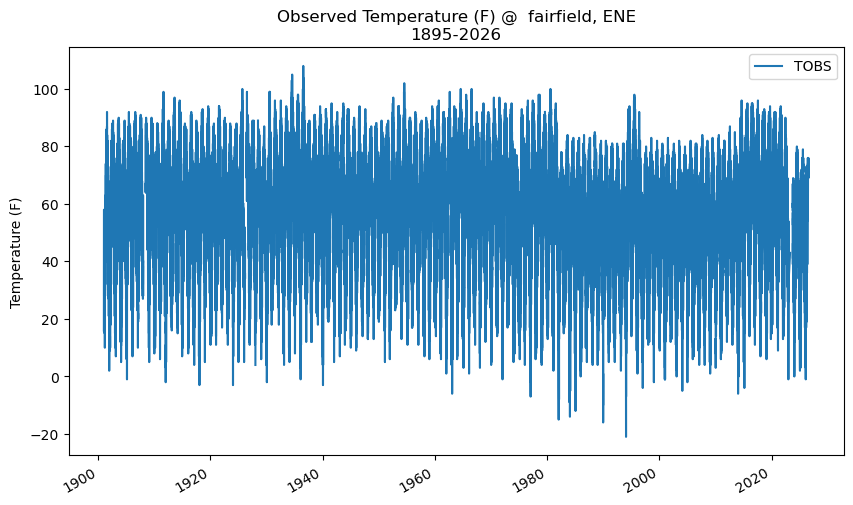

In [77]:
# Plot data with matplotlib

fig, ax = plt.subplots(figsize=(10,6))

fairfield_df.plot(y='TOBS',

                 ax=ax,

                 ylabel='Temperature (F)',

                 xlabel='',

                 title='Observed Temperature (F) @  fairfield, ENE\n1895-2026')

plt.show()

In [70]:
# Take the annual mean of the temperature data

ann_climate_df = fairfield_df.resample('YE').mean()

ann_climate_df

,TOBS
DATE,
1895-12-31,NaN
1896-12-31,NaN
1897-12-31,NaN
1898-12-31,NaN
1899-12-31,NaN
...,...
2022-12-31,54.589532
2023-12-31,44.116279
2024-12-31,51.945055


<Axes: xlabel='DATE'>

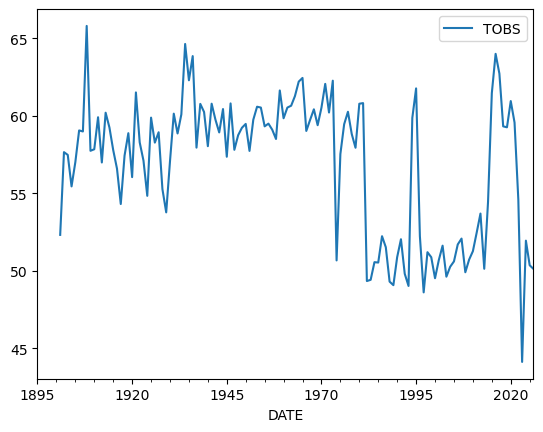

In [73]:
ann_climate_df.plot()

In [72]:
# Subset the data to look at last 10 years of data

fairfield_10yr = ann_climate_df.loc["2016": "2026"]

fairfield_10yr

,TOBS
DATE,
2016-12-31,64.005464
2017-12-31,62.728767
2018-12-31,59.324638
2019-12-31,59.263014
2020-12-31,60.956284
2021-12-31,59.571839
2022-12-31,54.589532
2023-12-31,44.116279
2024-12-31,51.945055


<Axes: xlabel='DATE'>

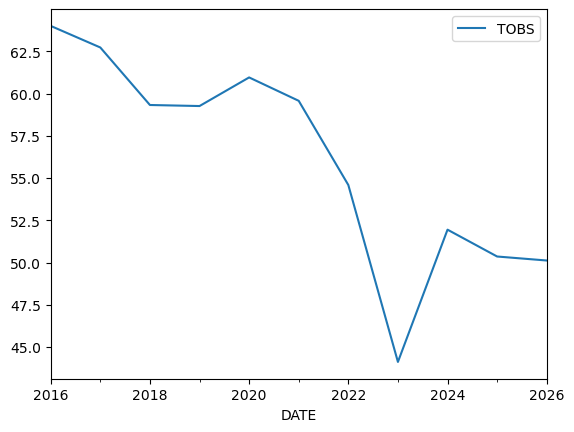

In [74]:
fairfield_10yr.plot()

In [75]:
# Subset the data to look at last 10 years of data but this time make it interactive

fairfield_10yr_plot = fairfield_10yr.hvplot()

fairfield_10yr_plot

:Curve   [DATE]   (TOBS)

In [76]:
# Save interactive plot as html to host on the web

hv.save(fairfield_10yr_plot, 'fairfield_plot.html')